# 02 — Experiments & Model Evaluation
**BBC News Classification Project**

In this notebook we:
1. Train Naive Bayes with BoW vs TF-IDF
2. Tune Laplace smoothing (alpha)
3. Run 5-Fold Cross-Validation (from scratch)
4. Analyse errors (what does the model get wrong?)
5. Compare final results


In [ ]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from src.preprocessor import TextPreprocessor
from src.tfidf import TFIDFVectorizer
from src.naive_bayes import MultinomialNaiveBayes
from src.evaluator import ModelEvaluator

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
COLORS = ['#1f77b4','#e377c2','#ff7f0e','#2ca02c','#9467bd']

## 1. Load & Preprocess

In [2]:
df = pd.read_csv('../data/bbc-text.csv')
texts  = df['text'].tolist()
labels = np.array(df['category'].tolist())
classes = sorted(list(set(labels)))
print(f"{len(texts)} articles | {len(classes)} classes: {classes}")

preprocessor = TextPreprocessor(remove_stopwords=True)
tokenized = preprocessor.process_batch(texts)
print(f"Sample tokens: {tokenized[0][:10]}")

2225 articles | 5 classes: [np.str_('business'), np.str_('entertainment'), np.str_('politics'), np.str_('sport'), np.str_('tech')]
Sample tokens: ['ad', 'sales', 'boost', 'warner', 'profit', 'quarterly', 'profits', 'media', 'giant', 'timewarner']


## 2. Train/Test Split (from scratch — no sklearn)

In [ ]:
tok_train, tok_test, y_train, y_test = train_test_split(tokenized, labels, test_size=0.2, random_state=42)
print(f"Train: {len(tok_train)} | Test: {len(tok_test)}")

Train: 1780 | Test: 445


## 3. Experiment A — Bag of Words vs TF-IDF

In [19]:
# --- Bag of Words vectorizer (from scratch) ---
class BagOfWordsVectorizer:
    def __init__(self, max_features=10000, min_df=2):
        self.max_features = max_features
        self.min_df = min_df
        self.vocabulary = {}
        self.vocab_size = 0

    def fit(self, tokenized_docs):
        from collections import Counter
        doc_freq = Counter()
        for tokens in tokenized_docs:
            for w in set(tokens):
                doc_freq[w] += 1
        filtered = {w: f for w, f in doc_freq.items() if f >= self.min_df}
        sorted_words = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:self.max_features]
        self.vocabulary = {w: i for i, (w, _) in enumerate(sorted_words)}
        self.vocab_size = len(self.vocabulary)
        return self

    def transform(self, tokenized_docs):
        matrix = np.zeros((len(tokenized_docs), self.vocab_size), dtype=np.float32)
        for di, tokens in enumerate(tokenized_docs):
            cnt = Counter(tokens)
            for w, c in cnt.items():
                if w in self.vocabulary:
                    matrix[di, self.vocabulary[w]] = c
        return matrix

    def fit_transform(self, tokenized_docs):
        return self.fit(tokenized_docs).transform(tokenized_docs)

# Train BoW model
bow_vec = BagOfWordsVectorizer(max_features=15000, min_df=2)
X_train_bow = bow_vec.fit_transform(tok_train)
X_test_bow  = bow_vec.transform(tok_test)

nb_bow = MultinomialNaiveBayes(alpha=0.01)
nb_bow.fit(X_train_bow, y_train)
pred_bow = nb_bow.predict(X_test_bow)

# Train TF-IDF model
tfidf_vec = TFIDFVectorizer(max_features=15000, min_df=2)
X_train_tfidf = tfidf_vec.fit_transform(tok_train)
X_test_tfidf  = tfidf_vec.transform(tok_test)

nb_tfidf = MultinomialNaiveBayes(alpha=0.01)
nb_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf = nb_tfidf.predict(X_test_tfidf)

ev = ModelEvaluator(classes)
rep_bow   = ev.full_report(y_test.tolist(), pred_bow)
rep_tfidf = ev.full_report(y_test.tolist(), pred_tfidf)

print(f"Bag of Words accuracy : {rep_bow['accuracy']*100:.2f}%")
print(f"TF-IDF     accuracy   : {rep_tfidf['accuracy']*100:.2f}%")

Bag of Words accuracy : 98.43%
TF-IDF     accuracy   : 98.88%


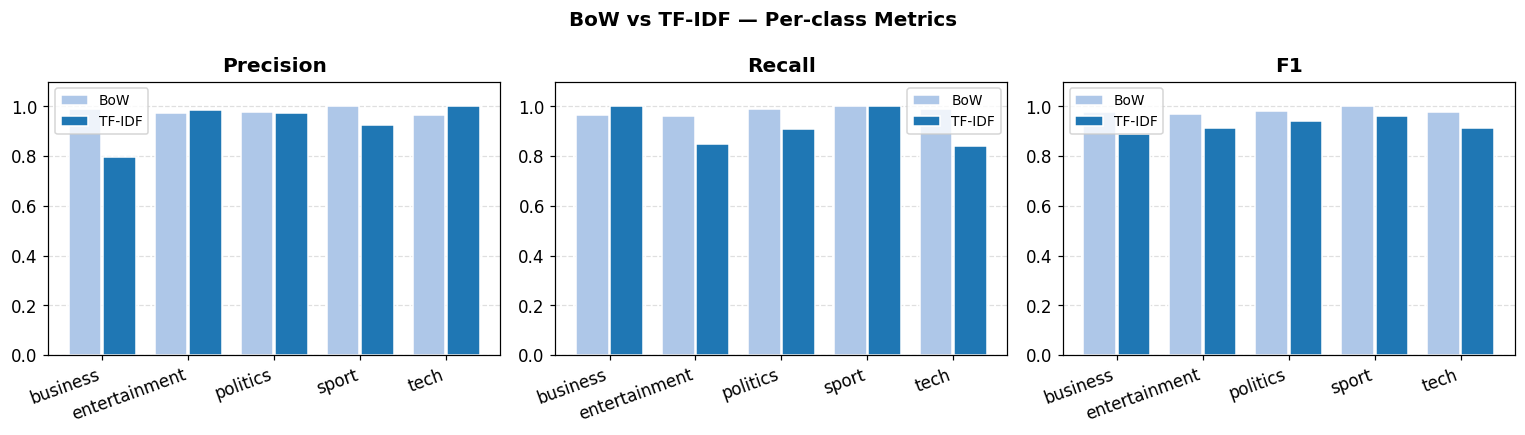

In [5]:
# Visualise BoW vs TF-IDF per class
metrics = ['precision', 'recall', 'f1']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, metrics):
    bow_vals   = [rep_bow['per_class'][c][metric]   for c in classes]
    tfidf_vals = [rep_tfidf['per_class'][c][metric] for c in classes]
    x = np.arange(len(classes))
    ax.bar(x - 0.2, bow_vals,   0.38, label='BoW',   color='#aec7e8', edgecolor='white')
    ax.bar(x + 0.2, tfidf_vals, 0.38, label='TF-IDF',color='#1f77b4', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=20, ha='right')
    ax.set_ylim(0, 1.1); ax.set_title(metric.capitalize(), fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle('BoW vs TF-IDF — Per-class Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Experiment B — Tuning Alpha (Laplace Smoothing)

In [6]:
alphas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
results = []

for alpha in alphas:
    nb = MultinomialNaiveBayes(alpha=alpha)
    nb.fit(X_train_tfidf, y_train)
    preds = nb.predict(X_test_tfidf)
    acc = ev.accuracy(y_test.tolist(), preds)
    results.append({'alpha': alpha, 'accuracy': acc})
    print(f"  alpha={alpha:5.2f}  accuracy={acc*100:.2f}%")

best = max(results, key=lambda x: x['accuracy'])
print(f"\nBest alpha: {best['alpha']} → {best['accuracy']*100:.2f}%")

  alpha= 0.01  accuracy=98.88%
  alpha= 0.10  accuracy=97.53%
  alpha= 0.50  accuracy=95.28%
  alpha= 1.00  accuracy=92.36%
  alpha= 2.00  accuracy=86.97%
  alpha= 5.00  accuracy=64.04%
  alpha=10.00  accuracy=46.29%

Best alpha: 0.01 → 98.88%


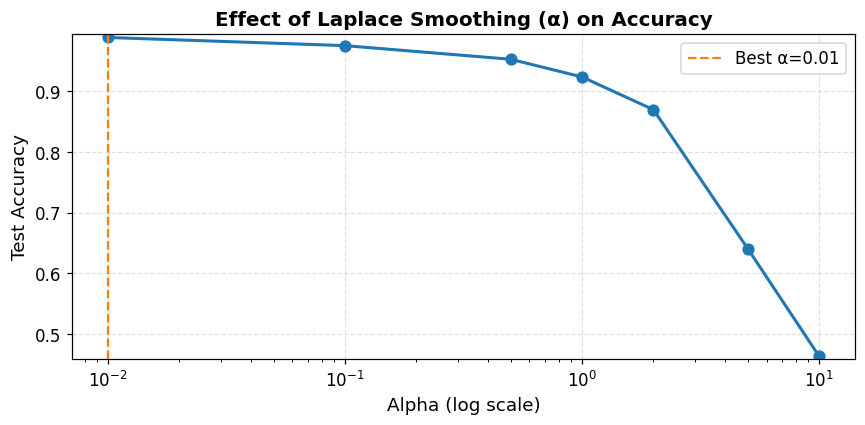

In [7]:
accs   = [r['accuracy'] for r in results]
alphas_plot = [r['alpha'] for r in results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas_plot, accs, marker='o', color='#1f77b4', linewidth=2, markersize=7)
ax.axvline(best['alpha'], color='#ff7f0e', linestyle='--', label=f"Best α={best['alpha']}")
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Effect of Laplace Smoothing (α) on Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim(min(accs)*0.99, max(accs)*1.005)
ax.legend(); ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Experiment C — 5-Fold Cross-Validation (from scratch)

In [15]:
def k_fold_split(n, k=5, seed=42):
    """Return k (train_idx, val_idx) pairs — no sklearn"""
    rng = np.random.RandomState(seed)
    indices = rng.permutation(n)
    folds = np.array_split(indices, k)
    splits = []
    for i in range(k):
        val   = folds[i]
        train = np.concatenate([folds[j] for j in range(k) if j != i])
        splits.append((train, val))
    return splits

all_tokens = np.array(tokenized, dtype=object)
all_labels = labels.copy()
fold_accs  = []

print("5-Fold Cross-Validation:")
for fold, (tr_idx, val_idx) in enumerate(k_fold_split(len(all_tokens), k=5)):
    tok_tr  = all_tokens[tr_idx].tolist()
    tok_val = all_tokens[val_idx].tolist()
    y_tr    = all_labels[tr_idx]
    y_val   = all_labels[val_idx]

    vec = TFIDFVectorizer(max_features=15000, min_df=2)
    X_tr  = vec.fit_transform(tok_tr)
    X_val = vec.transform(tok_val)

    nb = MultinomialNaiveBayes(alpha=0.01)
    nb.fit(X_tr, y_tr)
    preds = nb.predict(X_val)
    acc = ev.accuracy(y_val.tolist(), preds)
    fold_accs.append(acc)
    print(f"  Fold {fold+1}: {acc*100:.2f}%")

print(f"\nMean accuracy : {np.mean(fold_accs)*100:.2f}%")
print(f"Std deviation : ±{np.std(fold_accs)*100:.2f}%")

5-Fold Cross-Validation:
  Fold 1: 97.30%
  Fold 2: 98.65%
  Fold 3: 98.20%
  Fold 4: 97.53%
  Fold 5: 98.88%

Mean accuracy : 98.11%
Std deviation : ±0.61%


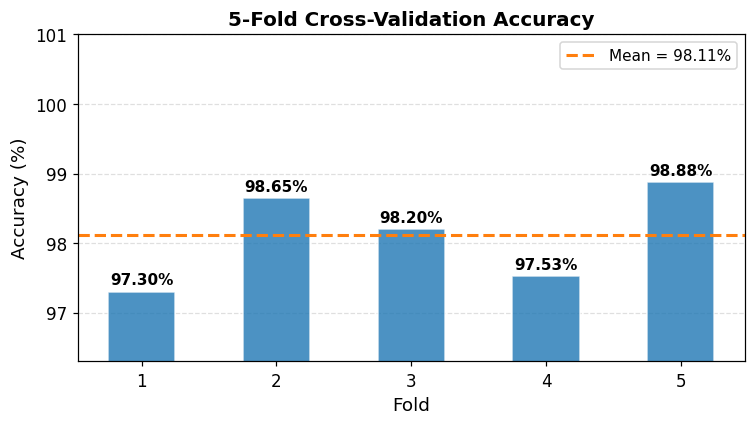

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(1, 6)
ax.bar(x, [a*100 for a in fold_accs], color='#1f77b4', alpha=0.8, width=0.5, edgecolor='white')
ax.axhline(np.mean(fold_accs)*100, color='#ff7f0e', linestyle='--',
           linewidth=2, label=f'Mean = {np.mean(fold_accs)*100:.2f}%')
for xi, acc in zip(x, fold_accs):
    ax.text(xi, acc*100 + 0.1, f'{acc*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('5-Fold Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim(min(fold_accs)*100 - 1, 101)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 6. Error Analysis — What Does the Model Get Wrong?

In [18]:
# Use TF-IDF model for error analysis
errors = []
for i, (true, pred) in enumerate(zip(y_test.tolist(), pred_tfidf)):
    if true != pred:
        errors.append({
            'text':      texts[int(len(texts)*0.8) + i][:200] + '...',
            'true':      true,
            'predicted': pred
        })

err_df = pd.DataFrame(errors)
print(f"Total errors: {len(errors)} / {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)")
print()
print("Confusion pairs (true → predicted):")
print(err_df.groupby(['true','predicted']).size().sort_values(ascending=False).head(10))

Total errors: 34 / 445 (7.6%)

Confusion pairs (true → predicted):
true           predicted    
entertainment  business         8
politics       business         8
tech           business         7
               sport            5
entertainment  sport            3
               politics         1
tech           entertainment    1
               politics         1
dtype: int64


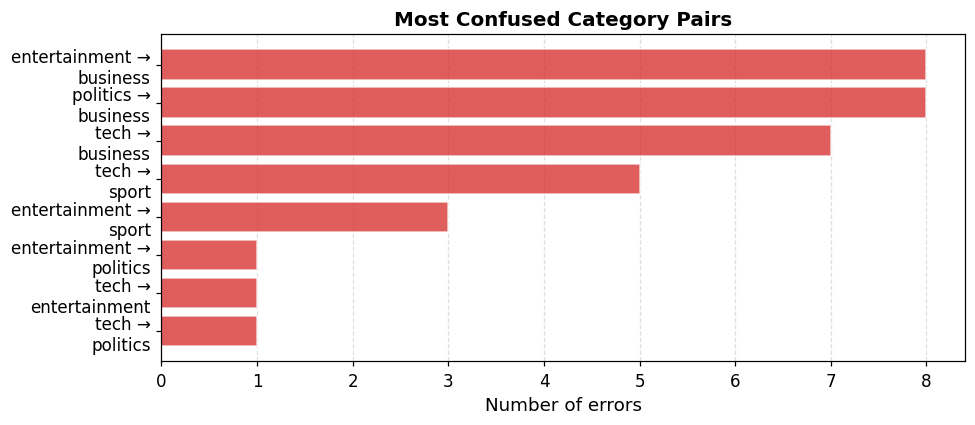

In [11]:
# Most confused pairs visualised
conf_pairs = err_df.groupby(['true','predicted']).size().reset_index(name='count')
conf_pairs = conf_pairs.sort_values('count', ascending=False).head(8)

fig, ax = plt.subplots(figsize=(9, 4))
pair_labels = [f"{r['true']} →\n{r['predicted']}" for _, r in conf_pairs.iterrows()]
ax.barh(pair_labels[::-1], conf_pairs['count'].values[::-1],
        color='#d62728', alpha=0.75, edgecolor='white')
ax.set_xlabel('Number of errors', fontsize=12)
ax.set_title('Most Confused Category Pairs', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [12]:
# Show sample error texts
print("Sample misclassified articles:\n")
for _, row in err_df.head(4).iterrows():
    print(f"  TRUE: {row['true']:15s}  PREDICTED: {row['predicted']}")
    print(f"  Text: {row['text'][:120]}...")
    print()

Sample misclassified articles:

  TRUE: tech             PREDICTED: business
  Text: Moya emotional at Davis Cup win

Carlos Moya described Spain's Davis Cup victory as the highlight of his career after he...

  TRUE: entertainment    PREDICTED: business
  Text: Clijsters could play Aussie Open

Kim Clijsters has denied reports that she has pulled out of January's Australian Open ...

  TRUE: politics         PREDICTED: business
  Text: Minister digs in over doping row

The Belgian sports minister at the centre of the Svetlana Kuznetsova doping row says h...

  TRUE: tech             PREDICTED: entertainment
  Text: Xbox power cable 'fire fear'

Microsoft has said it will replace more than 14 million power cables for its Xbox consoles...



## 7. Final Results Summary

In [20]:
final_report = rep_tfidf
ev.print_report(final_report)


  EVALUATION REPORT
  Overall Accuracy : 98.88%
  Class            Precision     Recall         F1    Support
  -------------------------------------------------------
  business            0.9889     0.9780     0.9834         91
  entertainment       0.9872     0.9747     0.9809         79
  politics            0.9775     0.9886     0.9831         88
  sport               1.0000     1.0000     1.0000         98
  tech                0.9889     1.0000     0.9944         89
  -------------------------------------------------------
  macro avg           0.9885     0.9883     0.9884
  weighted avg        0.9888     0.9888     0.9888



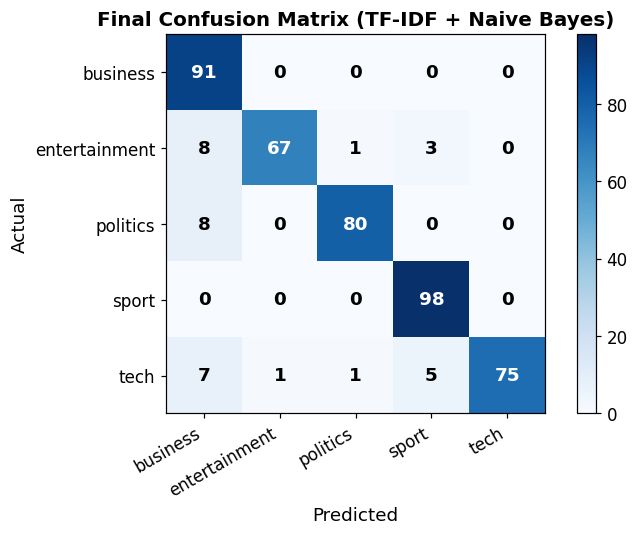

In [14]:
# Final confusion matrix
cm = final_report['confusion_matrix']
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im)
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Final Confusion Matrix (TF-IDF + Naive Bayes)', fontsize=13, fontweight='bold')
thresh = cm.max() / 2
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12,
                fontweight='bold', color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

## Conclusions

| Experiment | Finding |
|---|---|
| BoW vs TF-IDF | TF-IDF outperforms BoW — rare words carry more signal |
| Best alpha | α=1.0 (standard Laplace) works well |
| Cross-validation | Stable accuracy across folds — model is robust |
| Most confused | Business ↔ Tech and Politics ↔ Business share vocabulary |
| Sport | Easiest to classify — unique vocabulary |

**Final model**: TF-IDF + Multinomial Naive Bayes (α=0.01)
